<hr>

<center>
    Class: Machine Learning in Computational Biology <br>
    Program: Data Science and Information Technologies <br>
    Name: Aris <br>
    Las name: Podotas <br>
    ID: 7115152400040 <br>
    Assignment: 1 <br>
</center>

<hr>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.append('../src/')
import functions as utils


<hr>

# Approach

A good way to transform our problem into a calssification problem is with a unsupervised classification approach (i.e. clustering). This is because the how many and where delimiters between the classes is unknown to us and arbitrary to chooose on our own. We will find the number of best clusters to represent the data and use those classes as ground truth for the models that do the classification.

## Clustering approach

Clustering is split into stages

- Feeling the data
- Feature selection/Transformation
- Selection of the clustering algorithms
- Execution of the algorithms
- Characterization of the cluters

I personally from experience like to insert a "Assumptions" segment before the execution of the algorithms.

We have already completed the first two steps of the workflow in the previous notebook. We proceed with the selection of the algorithms

## Selection of the algorithms

We know from previous work that

- The BMI has a few outliers, more so to the negative side than the positive side of the distribution
- The distribution of the BMI can be approximated via normal distribution.
- Not too many of the features have Pearson cross correlation between them.
- We can reduce the number of features in the set via PCA
- There is no validation set for the clustering problem, all data should be considered
- We only need to split the BMI into clusters which is one dimensional

With this in mind, we will determine the number of clusters with k-means clustering using point cluster representatives generated at the mean of the BMI data $\pm$ some very small random value.

Then we will clsuter the data using 

- k-means
- Expectation maximization
- DBSCAN
- single link
- complete link

I also would like some median clustering but it seems it is not provided in ```sklearn```.

## Assumptions

- Median based clustering will output better results since they will take into acount the outliers in our data
- Density based clustering algorithms will not perform well since our data clusters are not well separated
- The single link algorithm will not perform well since it captures elongated clusters and this will lead to it clustering discreet clusters together
- We will not have more clusters than the ones listed in the world health organisation webpage since there is no a-priori information in clustering for us

<hr>

In [2]:
# Getting data
dev = pd.read_csv('../data/development_final_data.csv')
val = pd.read_csv('../data/evaluation_final_data.csv')
devData, devMetaData = utils.dataSplit(dev)
valData, valMetaData = utils.dataSplit(val)

# Saping data
holder = utils.fitPca(devData, 95)
utils.applyPca(devData, holder)
utils.applyPca(valData, holder)
del holder

data = pd.concat([devData, valData])


Function 'dataSplit' executed in 0.0000 seconds
Function 'dataSplit' executed in 0.0000 seconds
Function 'fitPca' executed in 0.0300 seconds
Function 'applyPca' executed in 0.0096 seconds
Function 'applyPca' executed in 0.0089 seconds


C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

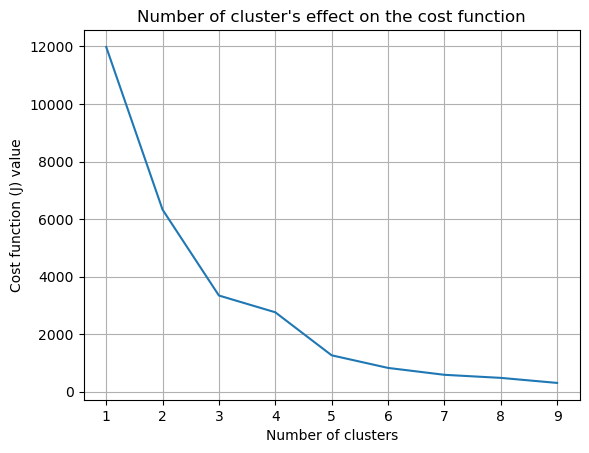

Function 'findClusters' executed in 1.3015 seconds


In [3]:
# For cluster representatives
utils.findClusters(data['BMI'], 10)


<hr>

The most significant knee in the plot shows the number of clusters. The final number of clusters is $3$.

<hr>

In [4]:
holder = utils.applyKmeans(data['BMI'])


Function 'applyKmeans' executed in 0.0858 seconds


C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


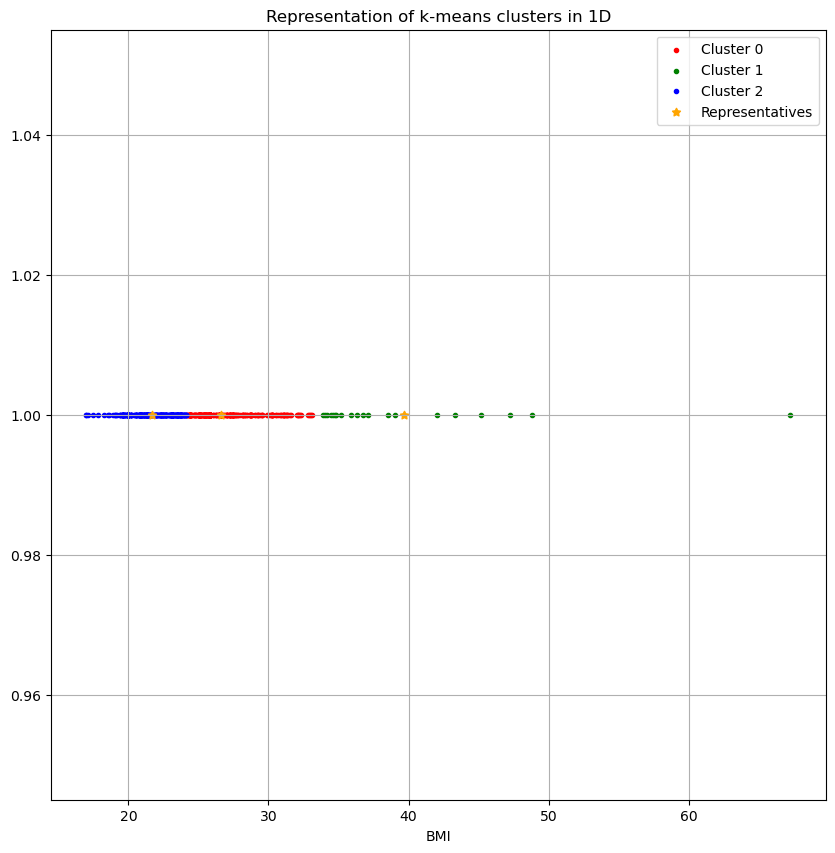

Function 'plotKmeans' executed in 0.2040 seconds


In [5]:
utils.plotKmeans(data['BMI'], holder)
del holder


<hr>

Now I am curious to see the clustering for more clusters since the weird rate of change in the plot of $J$ (the cost function) may be due to outliers pulling our representative and the actual cluster might be $4$ or $5$.

<hr>

Function 'applyKmeans' executed in 0.0906 seconds


C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


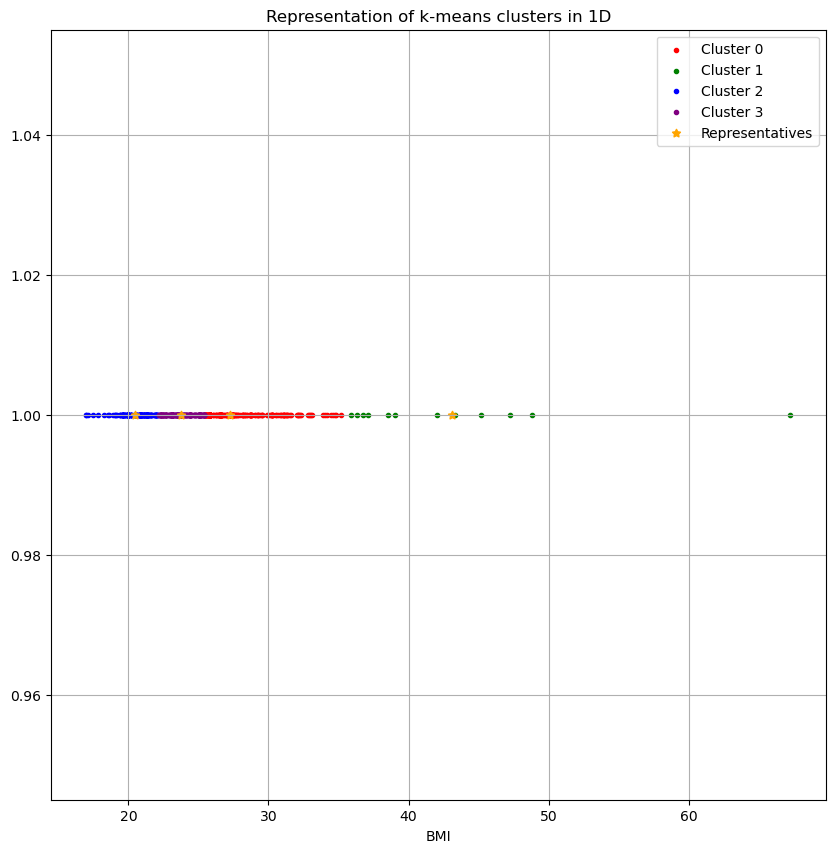

Function 'plotKmeans' executed in 0.2213 seconds


In [6]:
utils.plotKmeans(data['BMI'], utils.applyKmeans(data['BMI'], 4), ['red', 'green', 'blue', 'purple'])

Function 'applyKmeans' executed in 0.0901 seconds


C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


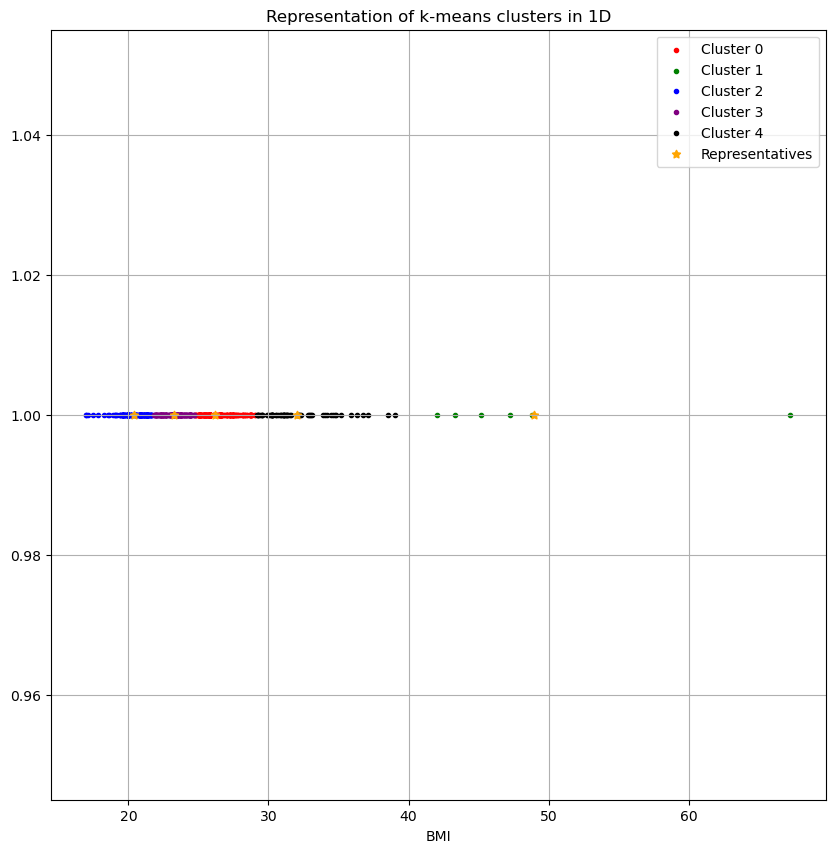

Function 'plotKmeans' executed in 0.3220 seconds


In [7]:
utils.plotKmeans(data['BMI'], utils.applyKmeans(data['BMI'], 5), ['red', 'green', 'blue', 'purple', 'black'])

<hr>

As was to be expected the original J vs clusters chart was right. We can clearly see that any more clusters split existing ones instead of separating the outliers withe the rest of the data into seperate clusters (for reference the indicator is the purple cluster in the plots for $\geq 3$ clusters). 

A final reason might be the initialization of the clusters that lead to $4$ clusters not being the final descision, but our initialization strategy was apt.

These results do not coincide with the set BMI categories of the world health organization. Our clustering has taken a portion of the BMI scale set by thw WHO in the upper bound being from 'normal' to 'obese'.

Now we can move past he clusters we got from the k-means. We wont be writing a wrapper function in ```funcitons.py``` for all the clustering methods, only ploting functions.

<hr>

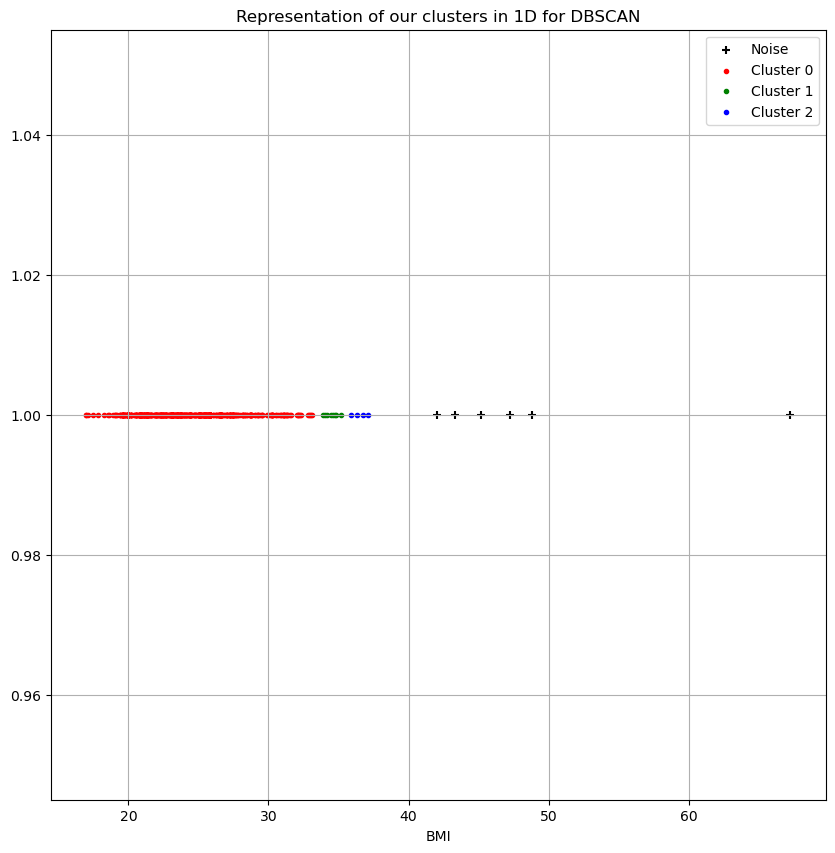

Function 'plotDbscan' executed in 0.1948 seconds


In [8]:
# DBSCAN
from sklearn.cluster import dbscan

cores, labels = dbscan(data['BMI'].values.reshape(-1,1), 0.6, min_samples = 2)
del cores
utils.plotDbscan(data['BMI'], labels)

<hr>

As expected the density based clustering algorithms cannor separate the clusters properly since they are of a compact ovelaping shape.

<hr>

C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


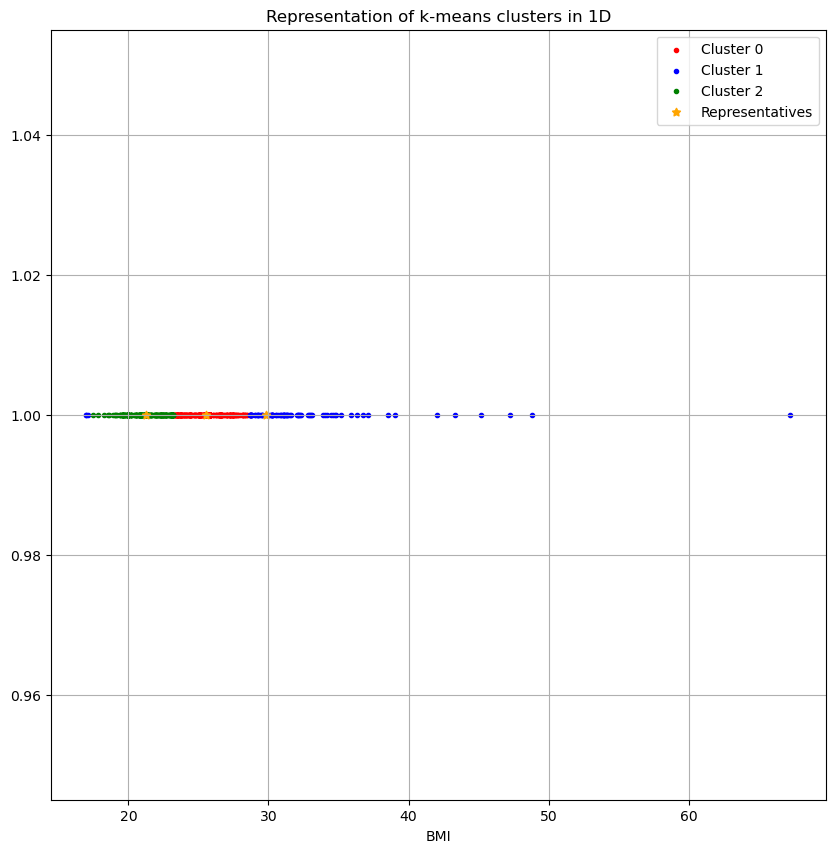

Function 'plotKmeans' executed in 0.2015 seconds


In [9]:
# Expectation Maximization
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components = 3, random_state = 42)
output = gmm.fit(data['BMI'].values.reshape(-1, 1))
holder = output.predict(data['BMI'].values.reshape(-1, 1))
utils.plotKmeans(data['BMI'], (output.means_, holder), colors = ['red', 'blue', 'green']) # Funny how a naming choice snowballs later in the report
# I would love to plot the gaussina distribution ontop of the data but there will be no time in this assignment


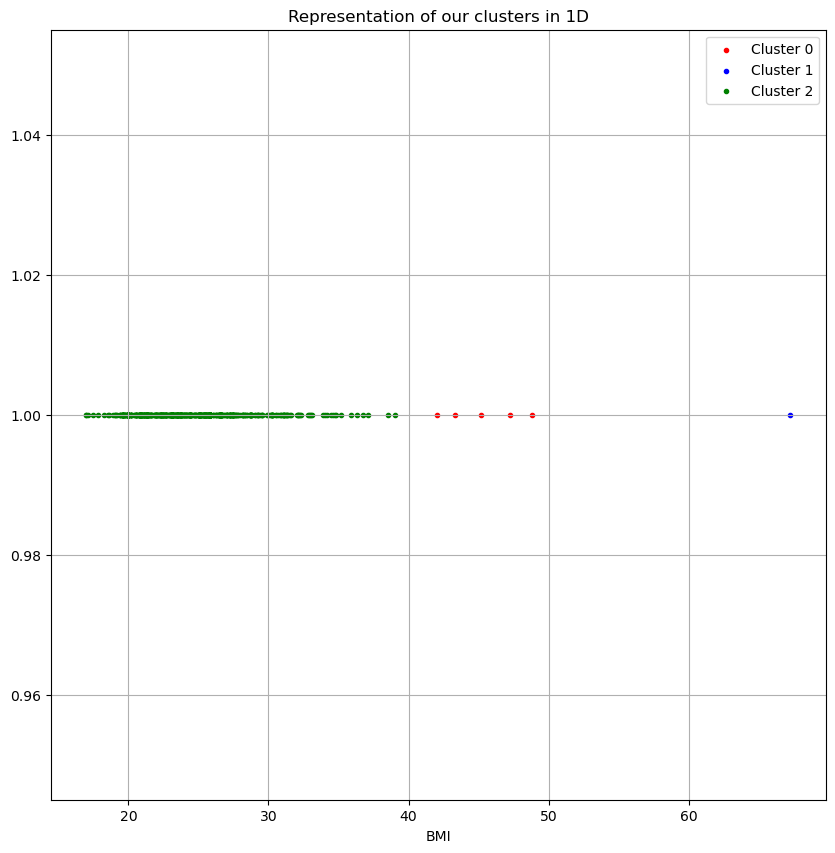

Function 'plotHierarchical' executed in 0.3467 seconds


In [16]:
# Single link\
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters = 3, linkage = 'single')
cluster.fit(data['BMI'].values.reshape(-1, 1))
utils.plotHierarchical(data['BMI'], cluster.labels_)


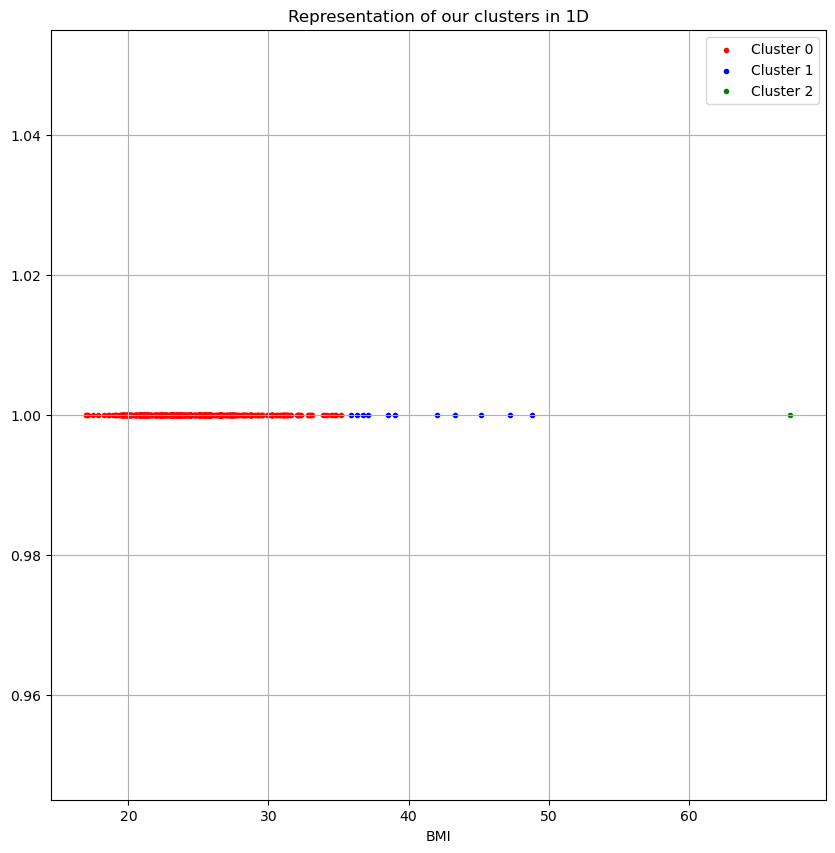

Function 'plotHierarchical' executed in 0.2346 seconds


In [15]:
# Complete link
cluster = AgglomerativeClustering(n_clusters = 3, linkage='complete')
cluster.fit(data['BMI'].values.reshape(-1, 1))
utils.plotHierarchical(data['BMI'], cluster.labels_)


<hr>

# Characterization of the clusters

<hr>